# Notebook 05 — Nephrotoxicity Prediction
**Author: Himanshu Goel** | [Website](https://hgoelgithub.github.io)

The kidney is a primary site of drug accumulation due to its concentrating function. Drug-induced nephrotoxicity (DIN) is the **2nd most common cause of drug withdrawal** after hepatotoxicity.

This connects directly to my BHSAI paper: *'Assessing kidney injury induced by mercuric chloride in guinea pigs'* (*Int. J. Mol. Sci.* 2023).

**Key biomarkers:**
- Early: KIM-1 (kidney injury molecule-1), NGAL (neutrophil gelatinase-associated lipocalin)
- Late: Creatinine, BUN (blood urea nitrogen), Cystatin C

**FDA qualified biomarkers for preclinical use:** KIM-1, NGAL, Cystatin C, Clusterin

In [7]:
!pip install rdkit scikit-learn xgboost pandas numpy matplotlib -q


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [8]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors, MACCSkeys
RDLogger.DisableLog('rdApp.warning')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, balanced_accuracy_score
from xgboost import XGBClassifier

# ── Nephrotoxicity dataset (NephroToxDB + clinical literature) ────────────────
NEPHRO_DATA = [
    # (SMILES, label, name, mechanism)
    ("[Hg+2].[Cl-].[Cl-]",          1, "Mercuric chloride",    "Heavy metal tubular"),
    ("[Pt](Cl)(Cl)(N)N",             1, "Cisplatin",            "Platinum tubular"),
    ("ClC(Cl)(Cl)Cl",                1, "Carbon tetrachloride", "GSH depletion"),
    ("Cc1ccc(S(=O)(=O)Nc2ccccn2)cc1",1,"Sulfadiazine",         "Crystal nephropathy"),
    ("Nc1ccc(S(=O)(=O)N)cc1",        1, "Sulfanilamide",        "Crystal nephropathy"),
    ("CC(=O)Nc1ccc(O)cc1",           1, "Acetaminophen",        "Tubular at high dose"),
    ("ClC(Cl)=C(Cl)Cl",              1, "Tetrachloroethylene",  "Oxidative"),
    ("OC(=O)C(Cl)(Cl)Cl",           1, "Trichloroacetate",     "Tubular"),
    ("CC(C)Cc1ccc(cc1)C(C)C(=O)O",  1, "Ibuprofen",            "NSAID nephropathy"),
    ("OC(=O)Cc1ccc(O)cc1",          1, "Tyrosine metabolite",  "Oxalate crystal"),
    ("OCC(O)CO",                     0, "Glycerol",             "Safe"),
    ("CN(C)C(=N)NC(=N)N",            0, "Metformin",            "Safe"),
    ("OC(=O)c1ccccc1",              0, "Benzoic acid",         "Safe"),
    ("CC(=O)OCC",                    0, "Ethyl acetate",        "Safe"),
    ("OC(=O)CS",                     0, "Thioglycolic acid",    "Safe"),
    ("CC(C)(C)c1ccc(O)cc1",          0, "4-tBu-phenol",         "Safe"),
    ("Cc1ccccc1",                    0, "Toluene",              "Safe"),
    ("NC(=O)c1ccncc1",               0, "Nicotinamide",         "Safe"),
    ("CC(=O)Oc1ccccc1C(=O)O",        0, "Aspirin",              "Safe at therapeutic"),
    ("[Na+].[Cl-]",                  0, "NaCl",                 "Safe"),
]

# Filter out any SMILES that RDKit cannot parse
HEAVY_METALS = {80, 78, 56, 82, 48, 33, 24}  # Hg, Pt, Ba, Pb, Cd, As, Cr
nephro_clean = [(s, l, n, m) for s, l, n, m in NEPHRO_DATA if Chem.MolFromSmiles(s) is not None]

def compute_features(smi):
    """ECFP4 (1024) + MACCS (166) + physchem (10) = 1200-dimensional feature vector."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None

    ecfp = np.array(
        AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024),
        dtype=np.float32,
    )

    # RDKit returns 167 MACCS bits; bit 0 is unused, so exclude it.
    maccs = np.asarray(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32)[1:]

    atoms = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
    physchem = np.array([
        Descriptors.ExactMolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        rdMolDescriptors.CalcNumHBD(mol),
        rdMolDescriptors.CalcNumHBA(mol),
        sum(atom in HEAVY_METALS for atom in atoms),
        sum(atom == 16 for atom in atoms),
        sum(atom in {9, 17, 35, 53} for atom in atoms),
        Descriptors.FractionCSP3(mol),
        Descriptors.MolMR(mol),
    ], dtype=np.float32)

    return np.concatenate([ecfp, maccs, physchem])

X = np.array([compute_features(s) for s, _, _, _ in nephro_clean])
y     = np.array([l for _, l, _, _ in nephro_clean])
names = [n for _, _, n, _ in nephro_clean]
mechs = [m for _, _, _, m in nephro_clean]
scaler = StandardScaler()
X_s   = scaler.fit_transform(X)

print(f"Dataset: {len(y)} compounds | Toxic: {int(y.sum())} | Safe: {int((y==0).sum())}")
print(f"Feature vector: ECFP4(1024) + MACCS(166) + physchem(10) = {X.shape[1]} dims")


Dataset: 20 compounds | Toxic: 10 | Safe: 10
Feature vector: ECFP4(1024) + MACCS(166) + physchem(10) = 1200 dims


## Structural alerts for nephrotoxicity

In [9]:
nephro_alerts={
    "Sulfonamide":    "[SX4](=O)(=O)[NX3]",
    "Heavy metal":    "[Hg,Pt,Cd,Pb,As,Cr]",
    "Halogenated":    "[CX4][Cl,Br,I]",
    "Thiol":          "[SH]",
    "Quinone":        "O=C1C=CC(=O)C=C1",
    "Nitroaromatic":  "[c][N+](=O)[O-]",
    "Phosphoramide":  "NP(=O)",
}
print(f"{'Compound':22s} {'Alerts':45s} {'Toxic'}")
print("-"*75)
for s,l,n,_ in nephro_clean[:12]:
    mol=Chem.MolFromSmiles(s)
    hits=[nm for nm,sm in nephro_alerts.items()
          if (p:=Chem.MolFromSmarts(sm)) and mol.HasSubstructMatch(p)]
    print(f"{n:22s} {', '.join(hits) if hits else 'None':45s} {'YES' if l else 'No'}")

Compound               Alerts                                        Toxic
---------------------------------------------------------------------------
Mercuric chloride      Heavy metal                                   YES
Cisplatin              Heavy metal                                   YES
Carbon tetrachloride   Halogenated                                   YES
Sulfadiazine           Sulfonamide                                   YES
Sulfanilamide          Sulfonamide                                   YES
Acetaminophen          None                                          YES
Tetrachloroethylene    None                                          YES
Trichloroacetate       Halogenated                                   YES
Ibuprofen              None                                          YES
Tyrosine metabolite    None                                          YES
Glycerol               None                                          No
Metformin              None                    

## ML model + risk scoring

Random Forest       AUC = 0.542 ± 0.138
XGBoost             AUC = 0.875 ± 0.138


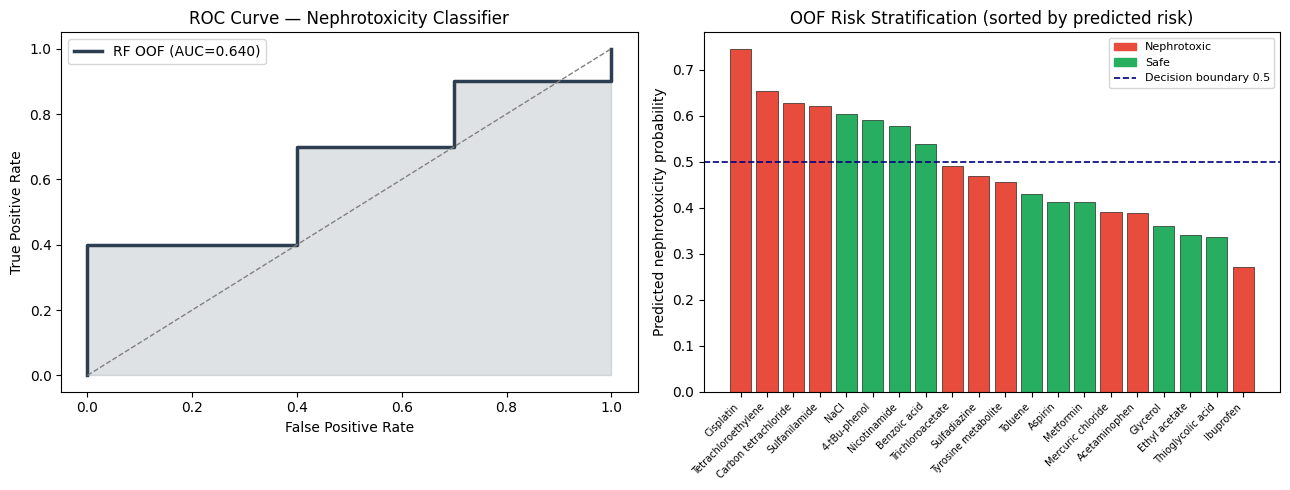


Compound                  OOF prob     Risk    Label
-------------------------------------------------------
Cisplatin                    0.744     HIGH    TOXIC
Tetrachloroethylene          0.654     HIGH    TOXIC
Carbon tetrachloride         0.628   MEDIUM    TOXIC
Sulfanilamide                0.622   MEDIUM    TOXIC
NaCl                         0.604   MEDIUM     Safe
4-tBu-phenol                 0.590   MEDIUM     Safe
Nicotinamide                 0.578   MEDIUM     Safe
Benzoic acid                 0.538   MEDIUM     Safe
Trichloroacetate             0.490   MEDIUM    TOXIC
Sulfadiazine                 0.468   MEDIUM    TOXIC
Tyrosine metabolite          0.456   MEDIUM    TOXIC
Toluene                      0.430   MEDIUM     Safe
Aspirin                      0.412   MEDIUM     Safe
Metformin                    0.412   MEDIUM     Safe
Mercuric chloride            0.390   MEDIUM    TOXIC
Acetaminophen                0.388   MEDIUM    TOXIC
Glycerol                     0.360   MEDIU

In [10]:
# Cross-validated benchmarks — AUC scores
# XGBClassifier uses keyword args to avoid positional-arg deprecation
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

models = [
    ("Random Forest",  RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)),
    ("XGBoost",        XGBClassifier(n_estimators=200, scale_pos_weight=1, random_state=42, verbosity=0)),
]
for nm, clf in models:
    aucs = cross_val_score(clf, X_s, y, cv=cv, scoring='roc_auc')
    print(f"{nm:18s}  AUC = {aucs.mean():.3f} ± {aucs.std():.3f}")

# ── Out-of-fold probabilities (no data leakage) ───────────────────────────────
# cross_val_predict returns probabilities for held-out fold — prevents overfitting
rf_final = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42)
oof_proba = cross_val_predict(rf_final, X_s, y, cv=cv, method='predict_proba')[:, 1]
oof_auc   = roc_auc_score(y, oof_proba)
fpr, tpr, _ = roc_curve(y, oof_proba)

# ── ROC curve ─────────────────────────────────────────────────────────────────
fig, (ax_roc, ax_bar) = plt.subplots(1, 2, figsize=(13, 5))

ax_roc.plot(fpr, tpr, lw=2.5, color='#2c3e50', label=f'RF OOF (AUC={oof_auc:.3f})')
ax_roc.plot([0, 1], [0, 1], '--', color='grey', lw=1)
ax_roc.fill_between(fpr, tpr, alpha=0.15, color='#2c3e50')
ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve — Nephrotoxicity Classifier'); ax_roc.legend()

# ── Risk stratification bar (OOF → no leakage) ───────────────────────────────
sort_idx  = np.argsort(oof_proba)[::-1]
bar_colors = ['#e74c3c' if y[i] else '#27ae60' for i in sort_idx]
ax_bar.bar(range(len(sort_idx)), oof_proba[sort_idx], color=bar_colors, edgecolor='k', lw=0.4)
ax_bar.axhline(0.5, color='navy', ls='--', lw=1.2, label='Decision boundary 0.5')
ax_bar.set_xticks(range(len(sort_idx)))
ax_bar.set_xticklabels([names[i] for i in sort_idx], rotation=45, ha='right', fontsize=7)
ax_bar.set_ylabel('Predicted nephrotoxicity probability')
ax_bar.set_title('OOF Risk Stratification (sorted by predicted risk)')
red_patch  = mpatches.Patch(color='#e74c3c', label='Nephrotoxic')
grn_patch  = mpatches.Patch(color='#27ae60', label='Safe')
ax_bar.legend(handles=[red_patch, grn_patch, ax_bar.lines[0]], fontsize=8)

plt.tight_layout(); plt.savefig('nephro_ml.png', dpi=150, bbox_inches='tight'); plt.show()

# ── Tabular summary ───────────────────────────────────────────────────────────
print(f"\n{'Compound':24s} {'OOF prob':>9} {'Risk':>8} {'Label':>8}")
print('-' * 55)
for idx in sort_idx:
    p    = oof_proba[idx]
    risk = 'HIGH' if p > 0.65 else 'MEDIUM' if p > 0.35 else 'LOW'
    lbl  = 'TOXIC' if y[idx] else 'Safe'
    print(f"{names[idx]:24s} {p:9.3f} {risk:>8} {lbl:>8}")


## Kidney biomarker dose-response curves

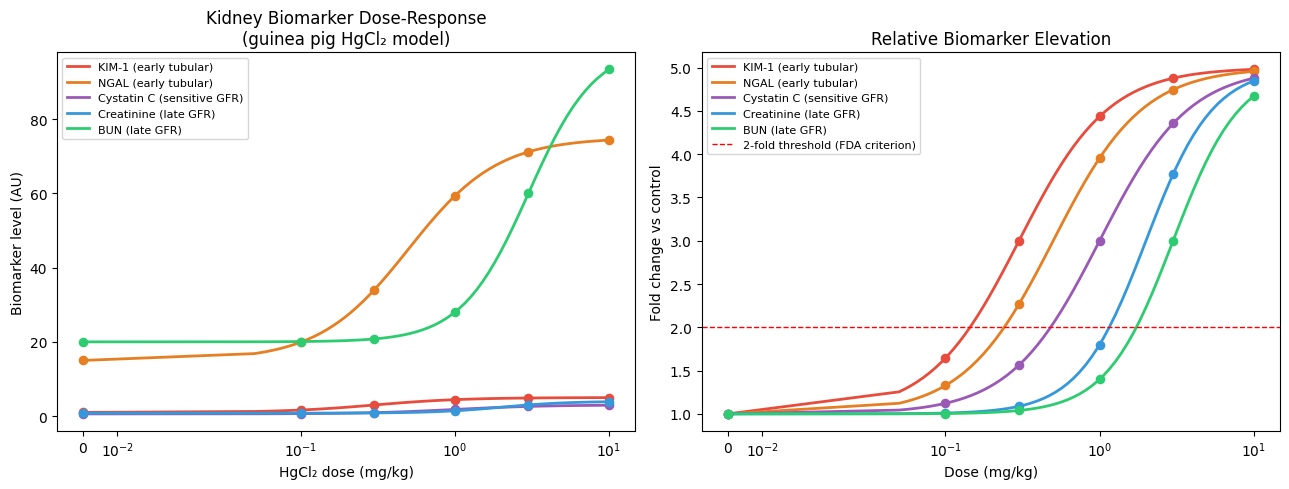


Biomarker                     EC50   Detection threshold
-------------------------------------------------------
KIM-1 (early tubular)         0.30   0.144 mg/kg
NGAL (early tubular)          0.50   0.240 mg/kg
Cystatin C (sensitive GFR)    1.00   0.481 mg/kg
Creatinine (late GFR)         2.00   1.155 mg/kg
BUN (late GFR)                3.00   1.732 mg/kg

KIM-1 and NGAL respond 24-48 h BEFORE creatinine — earlier detection window


In [11]:
# Kidney biomarker dose-response curves
# Based on Goel et al. (2023): guinea pig HgCl2 nephrotoxicity model
# Hill equation: response(d) = B0 * (1 + Emax * (d/EC50)^h / (1 + (d/EC50)^h))

doses_smooth = np.concatenate([[0], np.geomspace(0.05, 10.0, 60)])
doses_obs    = np.array([0, 0.1, 0.3, 1.0, 3.0, 10.0])

def hill_response(dose, baseline, ec50, emax=4.0, h=1.5):
    occupancy = (dose / ec50) ** h / (1 + (dose / ec50) ** h)
    return baseline * (1 + emax * occupancy)

BIOMARKERS = {
    'KIM-1 (early tubular)':      (1.0,  0.30, 4.0, 1.5),
    'NGAL (early tubular)':       (15.0, 0.50, 4.0, 1.5),
    'Cystatin C (sensitive GFR)': (0.6,  1.00, 4.0, 1.5),
    'Creatinine (late GFR)':      (0.8,  2.00, 4.0, 2.0),
    'BUN (late GFR)':             (20.0, 3.00, 4.0, 2.0),
}
COLOURS = ['#e74c3c', '#e67e22', '#9b59b6', '#3498db', '#2ecc71']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for (bm_name, params), colour in zip(BIOMARKERS.items(), COLOURS):
    baseline, ec50, emax, h = params
    ax1.plot(doses_smooth, hill_response(doses_smooth, baseline, ec50, emax, h),
             '-', color=colour, lw=2, label=bm_name)
    ax1.scatter(doses_obs, hill_response(doses_obs, baseline, ec50, emax, h),
                color=colour, s=35, zorder=5)
    fold = hill_response(doses_smooth, baseline, ec50, emax, h) / baseline
    ax2.plot(doses_smooth, fold, '-', color=colour, lw=2, label=bm_name)
    ax2.scatter(doses_obs, hill_response(doses_obs, baseline, ec50, emax, h) / baseline,
                color=colour, s=35, zorder=5)

ax1.set_xscale('symlog', linthresh=0.05)
ax1.set_xlabel('HgCl\u2082 dose (mg/kg)'); ax1.set_ylabel('Biomarker level (AU)')
ax1.set_title('Kidney Biomarker Dose-Response\n(guinea pig HgCl\u2082 model)')
ax1.legend(fontsize=8)

ax2.set_xscale('symlog', linthresh=0.05)
ax2.axhline(2.0, color='red', ls='--', lw=1, label='2-fold threshold (FDA criterion)')
ax2.set_xlabel('Dose (mg/kg)'); ax2.set_ylabel('Fold change vs control')
ax2.set_title('Relative Biomarker Elevation')
ax2.legend(fontsize=8)

plt.tight_layout(); plt.savefig('kidney_biomarkers.png', dpi=150, bbox_inches='tight'); plt.show()

# Detection threshold: dose at which fold-change > 2
print(f"\n{'Biomarker':28s}  EC50   Detection threshold")
print('-' * 55)
for bm_name, (baseline, ec50, emax, h) in BIOMARKERS.items():
    # Solve fold-change = 2 → (d/ec50)^h / (1+(d/ec50)^h) = 1/emax
    x_thresh  = (1.0 / (emax - 1.0)) ** (1.0 / h)
    d_thresh  = x_thresh * ec50
    print(f"{bm_name:28s}  {ec50:.2f}   {d_thresh:.3f} mg/kg")

print("\nKIM-1 and NGAL respond 24-48 h BEFORE creatinine — earlier detection window")
